---
title: "basic properties"
execute:
  # echo: false
  freeze: auto  # re-render only when source changes
format:
  html:
    code-fold: true
    code-summary: "Show the code"
---

## $\det(\exp(A))=\exp(\text{tr}(A))$

We wish to prove that for a diagonalizable matrix $A$, the determinant of its exponential equals the exponential of its trace:

$$
\det(\exp(A)) = \exp(\text{tr}(A))
$$

We start with the definition of the exponential function for a scalar $x$:

$$
\exp(x) = \sum_{n=0}^{\infty}\frac{x^n}{n!} = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \ldots
$$

We will extend this definition to include the exponential of a matrix $A$:

$$
\exp(A) = \sum_{n=0}^{\infty}\frac{A^n}{n!} = 1 + A + \frac{A^2}{2!} + \frac{A^3}{3!} + \ldots
$$

If $A$ is diagonalizable:

$$
A = P D P^{-1},
$$

where $P$ is a matrix whose column vectors are the eigenvectors of $A$, and $D$ is a diagonal matrix whose diagonal elements are the corresponding eigenvalues.

Let's use the equation above in the definition of the exponential:

\begin{align*}
\exp(A) &= \exp\left(P D P^{-1}\right) \\
&= 1 + P D P^{-1} + \frac{1}{2!}\left(P D \cancel{P^{-1}}\right)\left(\cancel{P} D P^{-1}\right) + \ldots \\
&= P D^2 P^{-1} + P D P^{-1} + \frac{1}{2!}P D^2 P^{-1} + \frac{1}{3!}P D^3 P^{-1} + \ldots 
\end{align*}

If we left-multiply the last expression by $P^{-1}$ and then right-multiply it by $P$, we get

$$
P^{-1}\exp(A)P = 1 + D + \frac{D^2}{2!} + \frac{D^3}{3!} = \exp(D)
$$

and then reversing the left- and right-multiplications we finally have:

$$
\exp(A) = P \exp(D) P^{-1}.
$$

We are almost there! Let's take the determinant of both sides. In the step below we will use the following property of determinants: $\det(XY)=\det(X)\det(Y)$. This can be untuitively justified by interpreting the determinant as the rescaling of a parallelogram defined by the linear transformation of a matrix. The rescaled parallelogram after the operation $XY$ is scaled first by $Y$ and then by $X$, giving the expression we need. Continuing:

\begin{align*}
\det(\exp(A)) &= \det(P \exp(D) P^{-1}) \\
&= \det(P)\det(\exp(D))\det(P^{-1}) \\
&= \cancel{\det(P)}\det(\exp(D))\cancel{\det(P^{-1})} \\
&= e^{d_1}e^{d_2}e^{d_3}\ldots \\
&= \exp(d_1+d_2+d_3+\ldots) \\
&= \exp(\text{tr}(D))
\end{align*}

Now, all we have to do is to replace the trace of $D$ by the trace of $A$. Using the [property of the trace of a product](https://en.wikipedia.org/wiki/Trace_(linear_algebra)#Trace_of_a_product): $\text{tr}(XY)=\text{tr}(YX)$:

$$
\text{tr}(A) = \text{tr}(P D P^{-1}) = \text{tr}(\cancel{P^{-1}P} D) = \text{tr}(D).
$$

Finally:

$$
\det(\exp(A)) = \exp(\text{tr}(A))
$$

and that concludes the proof. $\blacksquare$

## conjugation

I'd like to thank Adam Frank for his blog post on [axiomtutor.com](https://www.axiomtutor.com/new-blog?offset=1725466035734) for helping me grasp intuitively the concept of conjugation.

Conjugation represents the idea that one operation can be seen from two different points of view. I'll start with a concrete example.

Say that $k$ represents a reflection across the $x$-axis, and $g$ represents a counter-clockwise rotation by an arbitrary angle $\theta$. See below these two operations applied on a heart shape.

In [45]:
#| code-summary: import libraries
import numpy as np
from matplotlib.patches import Arc, RegularPolygon
import matplotlib.pyplot as plt
from numpy import radians as rad

In [46]:
#| code-summary: define useful functions
def drawCirc(ax,radius,centX,centY,angle_,theta2_,color_='black',linewidth=3):
    #========Line
    arc = Arc([centX,centY],radius,radius,angle=angle_,
          theta1=0,theta2=theta2_,capstyle='round',linestyle='-',lw=linewidth,color=color_)
    ax.add_patch(arc)


    #========Create the arrow head
    endX=centX+(radius/2)*np.cos(rad(theta2_+angle_)) #Do trig to determine end position
    endY=centY+(radius/2)*np.sin(rad(theta2_+angle_))
    
    ax.add_patch(
        RegularPolygon(
            (endX, endY),
            numVertices=3,
            radius=radius/5,
            orientation=rad(angle_ + theta2_),
            color=color_
        )
    )

In [47]:
#| code-summary: define transformations
red = 'xkcd:vermillion'
blue = 'xkcd:cerulean'
t = np.linspace(0, 2*np.pi, 100)
x = 16* (np.sin(t)) ** 3
y = 13* np.cos(t) - 5 * np.cos(2*t) - 2 * np.cos(3*t) - np.cos(4*t)
heart = np.array([x, y])
flip_x = np.array([[1, 0], [0, -1]])
def rotate(theta):
    return np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
heart_x = flip_x @ heart
theta = np.atan(0.5)
heart_minus_theta = rotate(-theta) @ heart
heart_minus_theta_flipped = flip_x @ heart_minus_theta
heart_minus_theta_flipped_plus_theta = rotate(theta) @ heart_minus_theta_flipped
x_oblique_axis = np.array([-25, 25])
y_oblique_axis = 0.5 * x_oblique_axis
oblique_axis = np.array([x_oblique_axis, y_oblique_axis])
oblique_axis_minus_theta = rotate(-theta) @ oblique_axis
oblique_axis_minus_theta_plus_theta = rotate(theta) @ oblique_axis_minus_theta

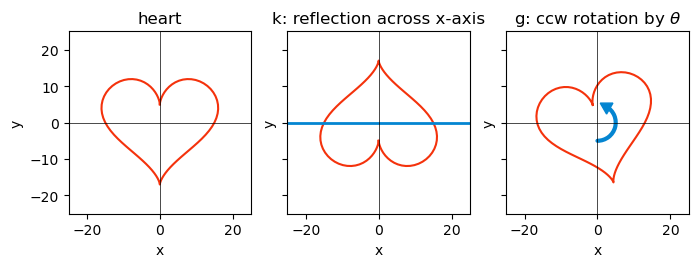

In [48]:
#| code-summary: plot k and g applied to a heart shape
fig, ax = plt.subplots(1, 3, sharey=True, figsize=(8, 4))
ax[0].plot(heart[0], heart[1], color=red)
ax[0].axhline(0, color='black', lw=0.5)
ax[0].axvline(0, color='black', lw=0.5)
ax[0].set_aspect('equal')
ax[0].set(xlabel='x', ylabel='y', title='heart', xlim=x_oblique_axis, ylim=x_oblique_axis)

ax[1].plot(heart_x[0], heart_x[1], color=red)
ax[1].axhline(0, color=blue, lw=2)
ax[1].axvline(0, color='black', lw=0.5)
ax[1].set_aspect('equal')
ax[1].set(xlabel='x', ylabel='y', title='k: reflection across x-axis', xlim=x_oblique_axis, ylim=x_oblique_axis)

heart_15 = rotate(np.pi/12) @ heart
ax[2].plot(heart_15[0], heart_15[1], color=red)
ax[2].axhline(0, color='black', lw=0.5)
ax[2].axvline(0, color='black', lw=0.5)
ax[2].set_aspect('equal')
ax[2].set(xlabel='x', ylabel='y', title=r'g: ccw rotation by $\theta$', xlim=x_oblique_axis, ylim=x_oblique_axis)
drawCirc(ax[2],radius=10,centX=0,centY=0,angle_=270,theta2_=150, color_=blue);

Because we are dealing with operations on a 2d plane, both $k$ and $g$ can be represented as $2\times2$ matrices:

$$
k =
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
\quad\text{and}\quad
g =
\begin{pmatrix}
\cos(\theta) & -\sin(\theta) \\
\sin(\theta) & \cos(\theta)
\end{pmatrix}
$$

What if we want to make a reflection of the heart shape across a different axis? In the graph below, the first panel on the left shows a reflection axis that is rotated by an angle $\theta$ from the $x$-axis. With a little ingenuity, I don't need to define a new reflection operation. Instead, I can use the existing reflection operation $k$ and the rotation operation $g$ to achieve the same effect.

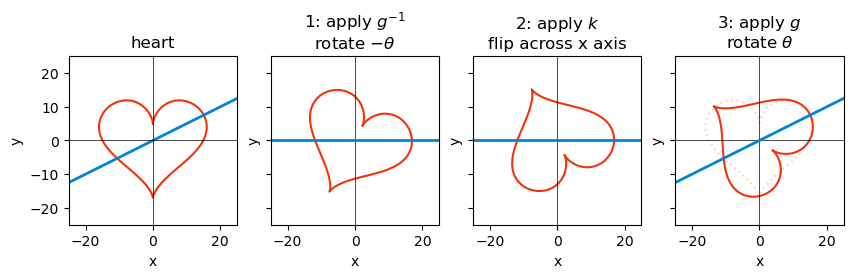

In [49]:
#| code-summary: conjugation of k and g applied to a heart shape
fig, ax = plt.subplots(1, 4, sharey=True, figsize=(10, 3))
ax[0].plot(heart[0], heart[1], color=red)
ax[0].plot(oblique_axis[0], oblique_axis[1], color=blue, lw=2)
ax[0].axhline(0, color='black', lw=0.5)
ax[0].axvline(0, color='black', lw=0.5)
ax[0].set_aspect('equal')
ax[0].set(xlabel='x', ylabel='y', title='heart', xlim=x_oblique_axis, ylim=x_oblique_axis)

ax[1].plot(heart_minus_theta[0], heart_minus_theta[1], color=red)
ax[1].axhline(0, color='black', lw=0.5)
ax[1].axvline(0, color='black', lw=0.5)
ax[1].plot(oblique_axis_minus_theta[0], oblique_axis_minus_theta[1], color=blue, lw=2)
ax[1].set_aspect('equal')
ax[1].set(xlabel='x', ylabel='y', title=r'1: apply $g^{-1}$' + "\n" + r'rotate $-\theta$', xlim=x_oblique_axis, ylim=x_oblique_axis)

ax[2].plot(heart_minus_theta_flipped[0], heart_minus_theta_flipped[1], color=red)
ax[2].axhline(0, color='black', lw=0.5)
ax[2].axvline(0, color='black', lw=0.5)
ax[2].plot(oblique_axis_minus_theta[0], oblique_axis_minus_theta[1], color=blue, lw=2)
ax[2].set(xlabel='x', ylabel='y', title=r'2: apply $k$' + "\n" + r'flip across x axis', xlim=x_oblique_axis, ylim=x_oblique_axis)
ax[2].set_aspect('equal')

ax[3].plot(heart_minus_theta_flipped_plus_theta[0], heart_minus_theta_flipped_plus_theta[1], color=red)
ax[3].plot(heart[0], heart[1], color=red, alpha=0.2, ls=":")
ax[3].axhline(0, color='black', lw=0.5)
ax[3].axvline(0, color='black', lw=0.5)
ax[3].plot(oblique_axis_minus_theta_plus_theta[0], oblique_axis_minus_theta_plus_theta[1], color=blue, lw=2)
ax[3].set(xlabel='x', ylabel='y', title=r'3: apply $g$' + "\n" + r'rotate $\theta$', xlim=x_oblique_axis, ylim=x_oblique_axis)
ax[3].set_aspect('equal');

1. We rotate the whole plane by an angle $-\theta$, which rotates the reflection axis (blue) to coincide with the $x$-axis (2nd panel). This is equivalent to applying the inverse of the rotation operation $g^{-1}$ to the heart shape.
2. Then we reflect the (rotated) heart shape across the $x$-axis (3rd panel). This is simply applying the reflection operation $k$ to the rotated heart shape.
3. Finally, we rotate the whole plane back by an angle $\theta$ (4th panel). This is equivalent to applying the rotation operation $g$ to the reflected heart shape. You can check the result by comparing the solid red curve with the original heart shape shown with a dotted line.

To sum up: apply $g^{-1}$, then $k$, then $g$. Let's call the resulting operation $k'$, which is said to be a conjugate of $k$ by $g$:

$$
k' = g k g^{-1}.
$$

Now let's see the same thing from a slightly different perspective. If $k$ means reflecting across the $x$-axis, then $k'$ can also be interpreted as reflecting across the $x$-axis, but in a rotated coordinate system. See below, the usual axes $x$ and $y$ are used in the panel on the left, while a rotated coordinate system by $\theta$ is used in the panel on the right.

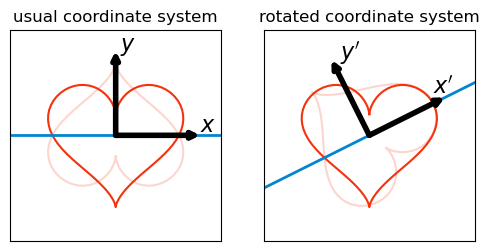

In [50]:
#| code-summary: conjugation of k and g applied to a heart shape
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(6, 3))

ax[0].plot(heart[0], heart[1], color=red)
ax[0].plot(heart_x[0], heart_x[1], color=red, alpha=0.2)
ax[0].axhline(0, color=blue, lw=2)
ax[0].set_aspect('equal')
ax[0].set(title='usual coordinate system', xlim=x_oblique_axis, ylim=x_oblique_axis, xticks=[], yticks=[])
ax[0].annotate("", xy=(20, 0), xytext=(0, 0), fontsize=10, color="black", arrowprops=dict(arrowstyle="->", facecolor='black', lw=4, shrinkA=0, shrinkB=0),)
ax[0].annotate("", xy=(0, 20), xytext=(0, 0), fontsize=10, color="black", arrowprops=dict(arrowstyle="->", facecolor='black', lw=4, shrinkA=0, shrinkB=0),)
ax[0].text(20, 1, r'$x$', fontsize=16, color="black")
ax[0].text(1, 20, r'$y$', fontsize=16, color="black")

ex = np.array([[20,0]])
x_prime = rotate(theta) @ ex.T
why = np.array([[0,20]])
y_prime = rotate(theta) @ why.T

ax[1].plot(heart[0], heart[1], color=red)
ax[1].plot(heart_minus_theta_flipped_plus_theta[0], heart_minus_theta_flipped_plus_theta[1], color=red, alpha=0.2)
ax[1].plot(oblique_axis[0], oblique_axis[1], color=blue, lw=2)
ax[1].set_aspect('equal')
ax[1].set(title='rotated coordinate system', xlim=x_oblique_axis, ylim=x_oblique_axis, xticks=[], yticks=[])
ax[1].annotate("", xy=x_prime, xytext=(0, 0), fontsize=10, color="black", arrowprops=dict(arrowstyle="->", facecolor='black', lw=4, shrinkA=0, shrinkB=0),)
ax[1].annotate("", xy=y_prime, xytext=(0, 0), fontsize=10, color="black", arrowprops=dict(arrowstyle="->", facecolor='black', lw=4, shrinkA=0, shrinkB=0),)
ax[1].text(15, 10, r"$x'$", fontsize=16, color="black")
ax[1].text(-7, 18, r"$y'$", fontsize=16, color="black");

The rotated coordinate system is defined by unit vectors $x'$ and $y'$ which are exactly the column vectors of the rotation matrix $g$!

So, another way to interpret the conjugation $k' = g k g^{-1}$ is that it represents the same operation $k$ (reflection across the $x$-axis), but in a rotated coordinate system defined by $g$.

The idea of conjugation is very general and can be applied to any operation, not just reflections. The one requirement is that the operation $g$ must be invertible, so that we can apply $g^{-1}$ to reverse the effect of $g$.

The underlying principle behind this generality is the "change-of-basis" formula. If $M$ is the matrix of an operation $k$ in a given basis, and $g$ is an invertible matrix whose column vectors define a new basis, then

$$
g^{-1}Mg
$$

is the matrix of the same operator written in the basis whose vectors are the columns of $g$.

Conjugation by $g$ preserves many properties of the operation $k$.

* The determinant of $k'$ is the same as the determinant of $k$.
* The trace of $k'$ is the same as the trace of $k$.
* The eigenvalues of $k'$ are the same as the eigenvalues of $k$. (The eigenvectors are rotated by $g$).
* The conjugation of a bracket of two operations is the same as the bracket of the conjugated operations:
  \begin{align*}
   [k, l]' &= g [k, l] g^{-1} \\
   &= g (kl - lk) g^{-1} \\
   &= gklg^{-1} - glkg^{-1} \\
   &= gkg^{-1}glg^{-1} - glg^{-1}gkg^{-1} \\
   &= (gkg^{-1})(glg^{-1}) - (glg^{-1})(gkg^{-1}) \\
   &= [gkg^{-1}, glg^{-1}] \\
   &= [k', l']
  \end{align*}